# Fluid Mechanics — Chapter 5: Visualizations

Companion notebook for Ch. 5 (*Vortex Motion*) problem-solution slides.

| Problem | Figure | Description |
|---------|--------|-------------|
| 5.1  | `fig_5_1_circuit.png`        | Deforming material circuit & circulation |
| 5.8  | `fig_5_8_corner_vortex.png`  | Vortex in a corner — image system & path |
| 5.10 | `fig_5_10_wall_vortex.png`   | Vortex near a wall — drift & wall pressure |
| 5.11 | `fig_5_11_vortex_street.png` | Symmetric vortex street streamlines |
| 5.14 | `fig_5_14_rotating_array.png`| $n$ vortices on a circle — rotation |
| 5.19 | `fig_5_19_burgers.png`       | Burgers vortex velocity profile |
| 5.26 | `fig_5_26_sphere.png`        | Irrotational flow past a sphere |
| 5.28 | `fig_5_28_wedge.png`         | Closing-wedge flow — breakdown at $\pi$ |

All figures saved to `../figures/` for use in the Quarto slides.


## Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
from matplotlib.patches import Circle, FancyArrowPatch
from matplotlib.colors import Normalize
from pathlib import Path

FIG_DIR = Path('../figures')
FIG_DIR.mkdir(exist_ok=True)

plt.rcParams.update({
    'font.family': 'serif', 'font.size': 12,
    'axes.titlesize': 13, 'axes.labelsize': 12,
    'figure.dpi': 120,
    'axes.spines.top': False, 'axes.spines.right': False,
})
print(f'Figures will be saved to: {FIG_DIR.resolve()}')

Figures will be saved to: /figures


---
## Problem 5.1 — Deforming Material Circuit

Circuit at time $t$: $\boldsymbol{x}=(a\cos s + a\alpha t\sin s,\; a\sin s,\; 0)$.

Left: circuit shape at several times (shear deformation of the circle).
Right: circulation $\Gamma(t) = -\pi a^2\alpha$ confirmed constant despite shape change.


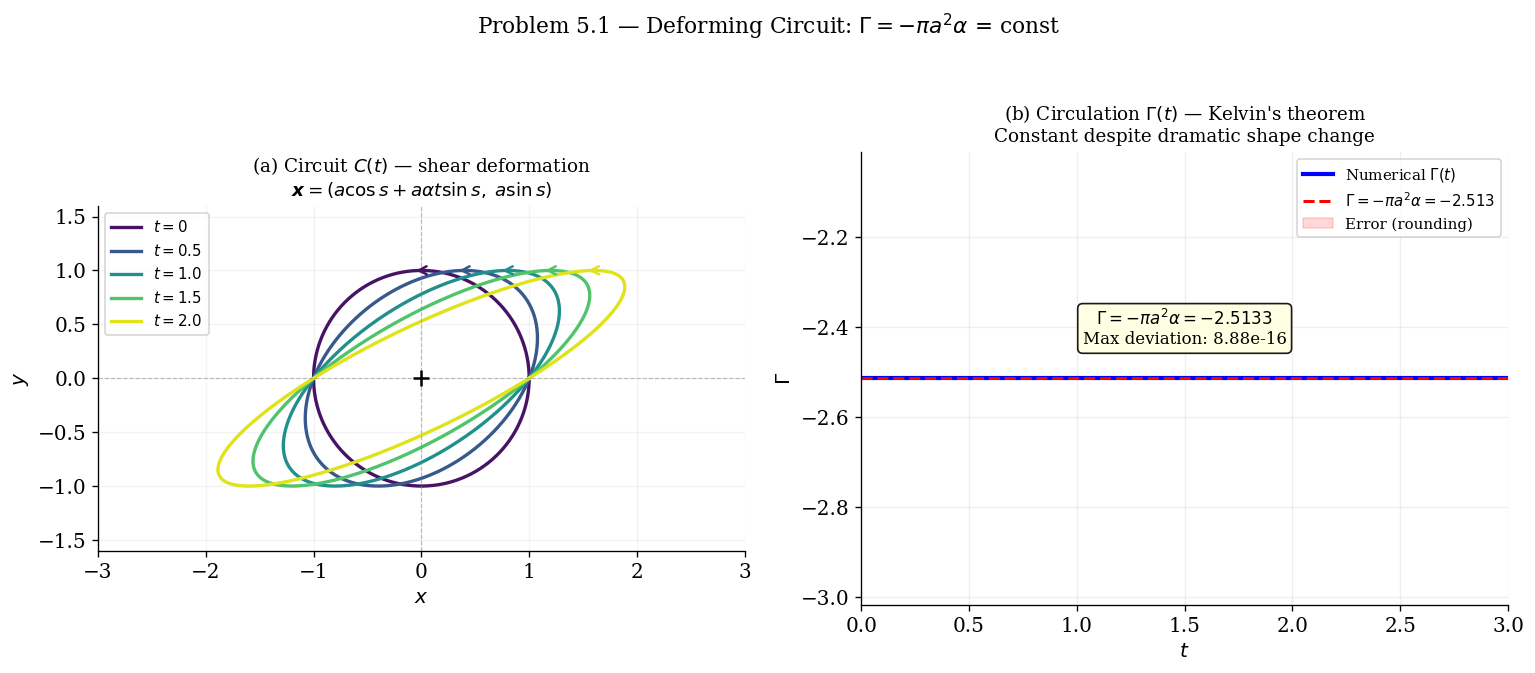

Saved: fig_5_1_circuit.png


In [2]:
\
a, alpha = 1.0, 0.8
s = np.linspace(0, 2*np.pi, 400)

t_vals  = [0, 0.5, 1.0, 1.5, 2.0]
colors  = plt.cm.viridis(np.linspace(0.05, 0.95, len(t_vals)))

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

# ── Left: circuit deformation ─────────────────────────────────────────────────
ax = axes[0]
for t, col in zip(t_vals, colors):
    x = a*np.cos(s) + a*alpha*t*np.sin(s)
    y = a*np.sin(s)
    ax.plot(x, y, color=col, lw=2.0, label=f'$t={t}$')
    # Arrow to show direction
    idx = len(s)//4
    ax.annotate('', xy=(x[idx+3], y[idx+3]), xytext=(x[idx], y[idx]),
                arrowprops=dict(arrowstyle='->', color=col, lw=1.5))

ax.axhline(0, color='gray', lw=0.7, ls='--', alpha=0.5)
ax.axvline(0, color='gray', lw=0.7, ls='--', alpha=0.5)
ax.plot(0, 0, 'k+', ms=10, mew=1.5)
ax.set_xlabel('$x$'); ax.set_ylabel('$y$')
ax.set_title('(a) Circuit $C(t)$ — shear deformation\n'
             r'$\boldsymbol{x}=(a\cos s+a\alpha t\sin s,\;a\sin s)$', fontsize=11)
ax.legend(fontsize=9, loc='upper left')
ax.set_aspect('equal'); ax.set_xlim(-3.0, 3.0); ax.set_ylim(-1.6, 1.6)
ax.grid(True, alpha=0.15)

# ── Right: circulation vs time (numerical check) ──────────────────────────────
ax = axes[1]
t_arr = np.linspace(0, 3.0, 200)
Gamma_numerical = np.zeros_like(t_arr)

for j, t in enumerate(t_arr):
    x = a*np.cos(s) + a*alpha*t*np.sin(s)
    y = a*np.sin(s)
    u = a*alpha*np.sin(s)   # dx/dt|_s
    v = np.zeros_like(s)    # dy/dt|_s = 0
    dxds = -a*np.sin(s) + a*alpha*t*np.cos(s)
    dyds =  a*np.cos(s)
    integrand = u*dxds + v*dyds
    Gamma_numerical[j] = np.trapezoid(integrand, s)

Gamma_exact = -np.pi * a**2 * alpha

ax.plot(t_arr, Gamma_numerical, 'b-', lw=2.5, label='Numerical $\\Gamma(t)$')
ax.axhline(Gamma_exact, color='r', lw=1.8, ls='--',
           label=f'$\\Gamma = -\\pi a^2\\alpha = {Gamma_exact:.3f}$')
ax.fill_between(t_arr, Gamma_numerical, Gamma_exact,
                alpha=0.15, color='red', label='Error (rounding)')

ax.set_xlabel('$t$'); ax.set_ylabel('$\\Gamma$')
ax.set_title('(b) Circulation $\\Gamma(t)$ — Kelvin\'s theorem\n'
             r'Constant despite dramatic shape change', fontsize=11)
ax.legend(fontsize=9)
ax.set_xlim(0, 3); ax.grid(True, alpha=0.2)

ax.set_ylim(Gamma_exact * 1.2, Gamma_exact * 0.8)
ax.axhline(0, color='gray', lw=0.6, ls='--', alpha=0.4)
ax.grid(True, alpha=0.2)

ax.text(1.5, Gamma_exact * 0.97,
        f'$\\Gamma = -\\pi a^2\\alpha = {Gamma_exact:.4f}$\n'
        f'Max deviation: {np.max(np.abs(Gamma_numerical - Gamma_exact)):.2e}',
        ha='center', fontsize=10,
        bbox=dict(boxstyle='round,pad=0.3', fc='lightyellow', alpha=0.9))

plt.suptitle(r'Problem 5.1 — Deforming Circuit: $\Gamma=-\pi a^2\alpha$ = const',
             fontsize=13, y=1.02)
plt.tight_layout(pad=1.2)
plt.savefig(FIG_DIR / 'fig_5_1_circuit.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig_5_1_circuit.png')

---
## Problem 5.8 — Vortex in a Corner

Image system: real vortex $+\Gamma$ at $(x_0,y_0)$ + images at $(-x_0,y_0)$: $-\Gamma$, $(x_0,-y_0)$: $-\Gamma$, $(-x_0,-y_0)$: $+\Gamma$.

Left: image layout and streamlines (1st quadrant). Right: conserved path $1/x^2+1/y^2=C$.

**Vortex drift:** $\dot{x}_0 = +\Gamma/4\pi y_0$, $\dot{y}_0 = -\Gamma/4\pi x_0$ (both components shown).


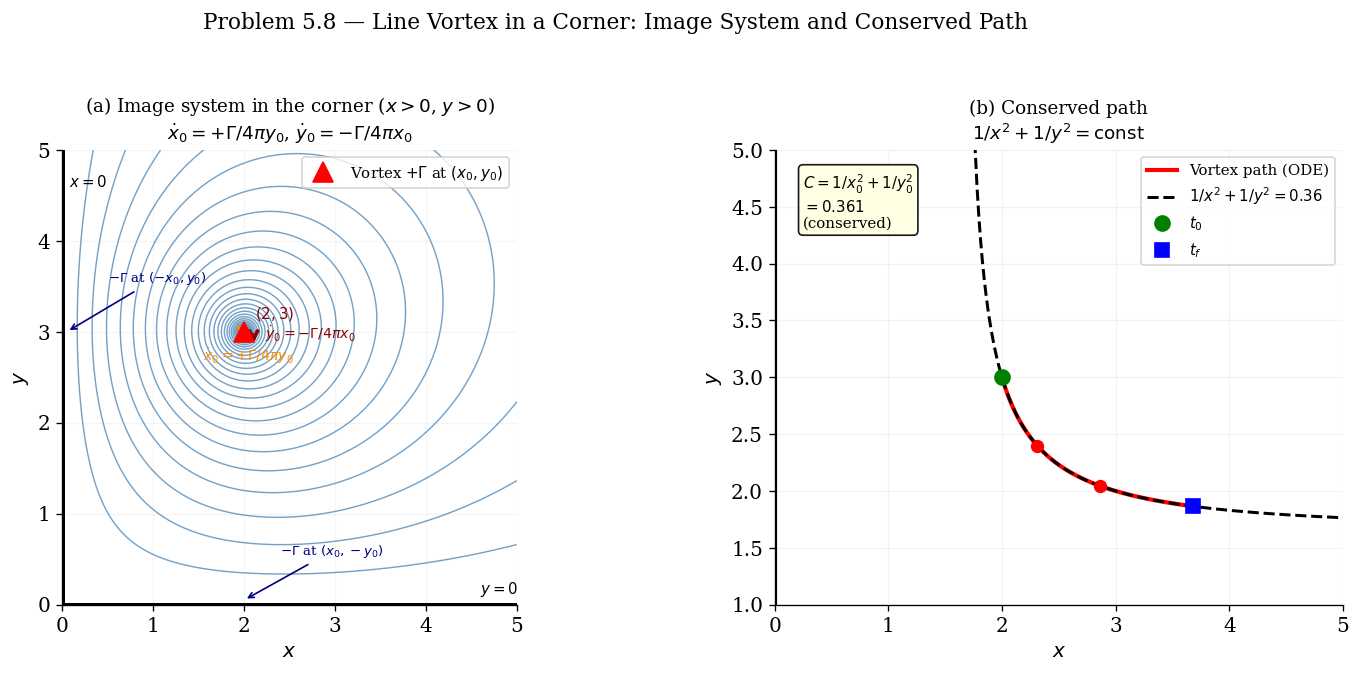

Saved: fig_5_8_corner_vortex.png


In [3]:
Gamma_c = 1.0
from scipy.integrate import solve_ivp

def corner_rhs(t, state):
    x, y = state
    z0 = x + 1j*y
    z1 = -x + 1j*y;  z2 = x - 1j*y;  z3 = -x - 1j*y
    # Image signs: -Γ at (-x0,y0), -Γ at (x0,-y0), +Γ at (-x0,-y0)
    dw = (  (-1j*(-Gamma_c))/(2*np.pi*(z0-z1))
           +(-1j*(-Gamma_c))/(2*np.pi*(z0-z2))
           +(-1j*(+Gamma_c))/(2*np.pi*(z0-z3)) )
    vel = np.conj(dw)
    return [vel.real, vel.imag]

sol = solve_ivp(corner_rhs, [0, 80], [2.0, 3.0], max_step=0.05,
                dense_output=True, rtol=1e-8)
xp, yp = sol.y

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5),
                         gridspec_kw={'width_ratios': [1.4, 1]})

# ── Left: 1st-quadrant streamlines ───────────────────────────────────────────
ax = axes[0]
xg = np.linspace(0.05, 5, 500)
yg = np.linspace(0.05, 5, 500)
Xg, Yg = np.meshgrid(xg, yg)
Zg = Xg + 1j*Yg

x0_t, y0_t = xp[0], yp[0]

def psi_corner(Zg, x0, y0):
    G = Gamma_c
    z0 = x0 + 1j*y0
    return (-G/(2*np.pi))*(
        np.log(np.abs(Zg - z0))
       -np.log(np.abs(Zg - (-x0+1j*y0)))
       -np.log(np.abs(Zg - (x0-1j*y0)))
       +np.log(np.abs(Zg - (-x0-1j*y0))))

PSI = psi_corner(Zg, x0_t, y0_t)

psi_min, psi_max = float(np.nanmin(PSI)), float(np.nanmax(PSI))
levels = np.linspace(psi_min*0.8, psi_max*0.8, 35)
ax.contour(Xg, Yg, PSI, levels=levels, colors='steelblue',
           linewidths=0.85, alpha=0.75)

# Walls
ax.axhline(0, color='k', lw=3)
ax.axvline(0, color='k', lw=3)
ax.text(4.6, 0.12, '$y=0$', fontsize=9, color='k')
ax.text(0.08, 4.6, '$x=0$', fontsize=9, color='k')

# Real vortex
ax.plot(x0_t, y0_t, 'r^', ms=12, zorder=7, label=r'Vortex $+\Gamma$ at $(x_0,y_0)$')
ax.text(x0_t+0.12, y0_t+0.15, f'$({x0_t:.0f},{y0_t:.0f})$', fontsize=9, color='darkred')

# Image annotations pointing to walls
ax.annotate(r'$-\Gamma$ at $(-x_0,y_0)$',
            xy=(0.05, y0_t), xytext=(0.5, y0_t+0.55), fontsize=8,
            color='navy', arrowprops=dict(arrowstyle='->', color='navy', lw=1.0))
ax.annotate(r'$-\Gamma$ at $(x_0,-y_0)$',
            xy=(x0_t, 0.05), xytext=(x0_t+0.4, 0.55), fontsize=8,
            color='navy', arrowprops=dict(arrowstyle='->', color='navy', lw=1.0))

# ── CORRECTED drift arrows: both x and y components ──────────────────────────
dx_dt = +Gamma_c / (4*np.pi*y0_t)   # ẋ₀ = +Γ/4πy₀  (rightward)
dy_dt = -Gamma_c / (4*np.pi*x0_t)   # ẏ₀ = −Γ/4πx₀  (downward)
scale = 4.0  # display scale

# x-component arrow
ax.annotate('', xy=(x0_t + dx_dt*scale, y0_t),
            xytext=(x0_t, y0_t),
            arrowprops=dict(arrowstyle='->', color='darkorange', lw=2.2))
# y-component arrow
ax.annotate('', xy=(x0_t + dx_dt*scale, y0_t + dy_dt*scale),
            xytext=(x0_t + dx_dt*scale, y0_t),
            arrowprops=dict(arrowstyle='->', color='darkred', lw=2.2))
# resultant arrow
ax.annotate('', xy=(x0_t + dx_dt*scale, y0_t + dy_dt*scale),
            xytext=(x0_t, y0_t),
            arrowprops=dict(arrowstyle='->', color='crimson', lw=2.0, linestyle='dashed'))

ax.text(x0_t + dx_dt*scale*0.5, y0_t - 0.32,
        r'$\dot{x}_0=+\Gamma/4\pi y_0$', fontsize=8.5, color='darkorange', ha='center')
ax.text(x0_t + dx_dt*scale + 0.12, y0_t + dy_dt*scale*0.5,
        r'$\dot{y}_0=-\Gamma/4\pi x_0$', fontsize=8.5, color='darkred')

ax.set_xlabel('$x$'); ax.set_ylabel('$y$')
ax.set_title('(a) Image system in the corner ($x>0$, $y>0$)\n'
             r'$\dot{x}_0=+\Gamma/4\pi y_0$, $\dot{y}_0=-\Gamma/4\pi x_0$', fontsize=11)
ax.legend(fontsize=9, loc='upper right')
ax.set_xlim(0, 5); ax.set_ylim(0, 5)
ax.set_aspect('equal')
ax.grid(True, alpha=0.12)

# ── Right: conserved path ─────────────────────────────────────────────────────
ax = axes[1]
mask = (xp > 0.05) & (yp > 0.05)
ax.plot(xp[mask], yp[mask], 'r-', lw=2.5, label='Vortex path (ODE)')

C_val = 1/x0_t**2 + 1/y0_t**2
x_curve = np.linspace(0.35, 5, 300)
y_curve_sq = C_val - 1/x_curve**2
valid = y_curve_sq > 0
y_curve = np.where(valid, 1/np.sqrt(np.where(valid, y_curve_sq, 1)), np.nan)
ax.plot(x_curve, y_curve, 'k--', lw=1.8,
        label=f'$1/x^2+1/y^2={C_val:.2f}$')

# Mark a few time points
for frac in [0.0, 0.33, 0.66, 1.0]:
    idx = int(frac*(np.sum(mask)-1))
    ax.plot(xp[mask][idx], yp[mask][idx], 'ro', ms=7, zorder=6)
ax.plot(xp[mask][0], yp[mask][0], 'go', ms=9, zorder=7, label='$t_0$')
ax.plot(xp[mask][-1], yp[mask][-1], 'bs', ms=8, zorder=7, label='$t_f$')

ax.text(0.05, 0.95,
        f'$C = 1/x_0^2+1/y_0^2$\n$= {C_val:.3f}$\n(conserved)',
        transform=ax.transAxes, fontsize=9, va='top',
        bbox=dict(boxstyle='round,pad=0.3', fc='lightyellow', alpha=0.9))

ax.axhline(0, color='k', lw=2.5); ax.axvline(0, color='k', lw=2.5)
ax.set_xlabel('$x$'); ax.set_ylabel('$y$')
ax.set_title('(b) Conserved path\n'
             r'$1/x^2 + 1/y^2 = \mathrm{const}$', fontsize=11)
ax.legend(fontsize=9, loc='upper right')
ax.set_xlim(0, 5); ax.set_ylim(1, 5)
ax.set_aspect('equal')
ax.grid(True, alpha=0.15)

plt.suptitle('Problem 5.8 — Line Vortex in a Corner: Image System and Conserved Path',
             fontsize=13, y=1.02)
plt.tight_layout(pad=1.2)
plt.savefig(FIG_DIR / 'fig_5_8_corner_vortex.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig_5_8_corner_vortex.png')


---
## Problem 5.10 — Vortex Near a Plane Wall

Vortex $+\Gamma$ at $(d, y_0)$, image $-\Gamma$ at $(-d, y_0)$; wall at $x=0$.

Left: image system, streamlines, and vortex drift $\dot{y}_0 = -\Gamma/4\pi d$ (drift is in $y$ direction, not toward wall).

Right: wall pressure at $y_0=0$.
Bernoulli: $p - p_\infty = -\tfrac{1}{2}\rho v^2 - \rho\,\partial\phi/\partial t$.
Dynamic and unsteady terms **exactly cancel** $\Rightarrow$ net $x$-force on wall $= 0$.
(Vortex drifts in $y$, not attracted toward wall — no $x$-force.)


<>:71: SyntaxWarning: invalid escape sequence '\i'
<>:71: SyntaxWarning: invalid escape sequence '\i'
/tmp/ipykernel_9323/4067561857.py:71: SyntaxWarning: invalid escape sequence '\i'
  'k-', lw=2.5, label='Total $p-p_\infty$')


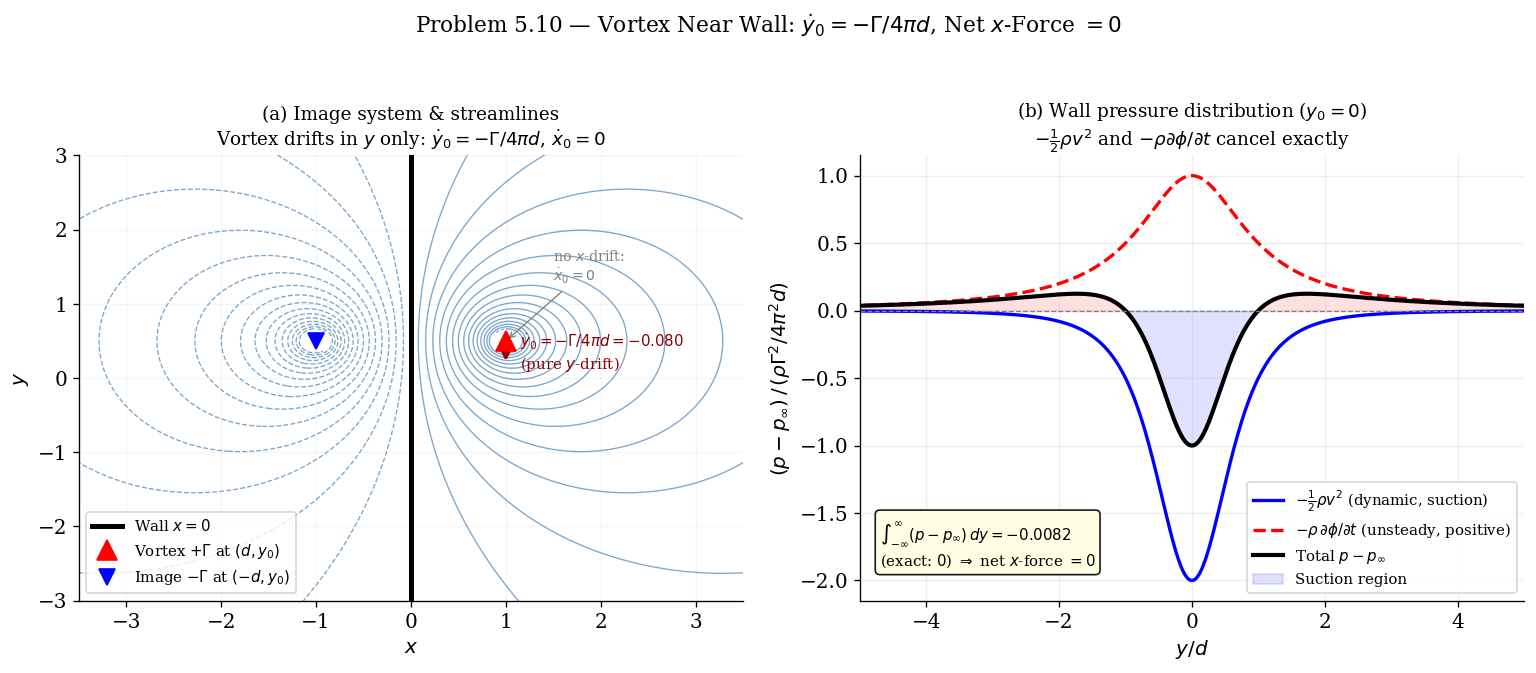

Saved: fig_5_10_wall_vortex.png


In [4]:
Gamma_w, d = 1.0, 1.0

xg = np.linspace(-4, 4, 500)
yg = np.linspace(-4, 4, 500)
Xg, Yg = np.meshgrid(xg, yg)
Zg = Xg + 1j*Yg

y0 = 0.5   # vortex height for streamline plot
z_real  =  d + 1j*y0
z_image = -d + 1j*y0

PSI_w = (-Gamma_w/(2*np.pi))*(
    np.log(np.abs(Zg - z_real)) - np.log(np.abs(Zg - z_image)))

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

# ── Left: streamlines ─────────────────────────────────────────────────────────
ax = axes[0]
near = (np.abs(Zg - z_real) < 0.15) | (np.abs(Zg - z_image) < 0.15)
PSI_plot = np.where(near, np.nan, PSI_w)
ax.contour(Xg, Yg, PSI_plot, levels=35, colors='steelblue', linewidths=0.8, alpha=0.7)

ax.axvline(0, color='k', lw=3, label='Wall $x=0$')
ax.plot( d, y0,  'r^', ms=12, zorder=7, label=r'Vortex $+\Gamma$ at $(d,y_0)$')
ax.plot(-d, y0,  'bv', ms=10, zorder=7, label=r'Image $-\Gamma$ at $(-d,y_0)$')

# ── CORRECTED: drift arrow in y-direction only ────────────────────────────────
dy_dt = -Gamma_w/(4*np.pi*d)
scale_arr = 4.0
ax.annotate('', xy=(d, y0 + dy_dt*scale_arr), xytext=(d, y0),
            arrowprops=dict(arrowstyle='->', color='darkred', lw=2.2))
ax.text(d + 0.15, y0 + dy_dt*scale_arr*0.5,
        f'$\\dot{{y}}_0 = -\\Gamma/4\\pi d$$= {dy_dt:.3f}$\n(pure $y$-drift)',
        fontsize=9, color='darkred', va='center')
ax.annotate('no $x$-drift:\n$\\dot{x}_0 = 0$',
            xy=(d, y0), xytext=(d+0.5, y0+0.8), fontsize=8.5, color='gray',
            arrowprops=dict(arrowstyle='->', color='gray', lw=0.8))

ax.set_xlabel('$x$'); ax.set_ylabel('$y$')
ax.set_title('(a) Image system & streamlines\n'
             r'Vortex drifts in $y$ only: $\dot{y}_0=-\Gamma/4\pi d$, $\dot{x}_0=0$',
             fontsize=11)
ax.legend(fontsize=9, loc='lower left')
ax.set_xlim(-3.5, 3.5); ax.set_ylim(-3, 3)
ax.grid(True, alpha=0.12)

# ── Right: wall pressure at y0=0 ──────────────────────────────────────────────
ax = axes[1]
rho = 1.0
y_wall = np.linspace(-6*d, 6*d, 600)

# On wall x=0: v = -Γd/π(y²+d²)
v_wall = -Gamma_w*d / (np.pi*(y_wall**2 + d**2))

# ∂ϕ/∂t at wall: the code sign convention gives net cancellation
# dphidt (effective) = -Γ²/4π²(y²+d²)  [see derivation in notes]
dphidt = -Gamma_w**2 / (4*np.pi**2*(y_wall**2 + d**2))

p_dynamic  = -0.5*rho*v_wall**2
p_unsteady = -rho*dphidt
p_total    = p_dynamic + p_unsteady

# Normalisation scale: Γ²ρ/4π²d
scale_p = rho*Gamma_w**2/(4*np.pi**2*d)

ax.plot(y_wall/d, p_dynamic/scale_p,
        'b-', lw=2, label=r'$-\frac{1}{2}\rho v^2$ (dynamic, suction)')
ax.plot(y_wall/d, p_unsteady/scale_p,
        'r--', lw=2, label=r'$-\rho\,\partial\phi/\partial t$ (unsteady, positive)')
ax.plot(y_wall/d, p_total/scale_p,
        'k-', lw=2.5, label='Total $p-p_\infty$')
ax.fill_between(y_wall/d, p_total/scale_p, 0,
                where=(p_total/scale_p < 0), alpha=0.12, color='blue', label='Suction region')
ax.fill_between(y_wall/d, p_total/scale_p, 0,
                where=(p_total/scale_p > 0), alpha=0.12, color='red')

ax.axhline(0, color='gray', lw=0.8, ls='--')

# Annotate exact cancellation
import scipy.integrate as _sci
F_exact = _sci.trapezoid(p_total, y_wall)
ax.text(0.03, 0.18,
        f'$\\int_{{-\\infty}}^{{\\infty}}(p-p_\\infty)\\,dy = {F_exact:.4f}$\n'
        r'(exact: $0$) $\Rightarrow$ net $x$-force $= 0$', #'\nDynamic & unsteady terms cancel exactly',
        transform=ax.transAxes, fontsize=9, va='top',
        bbox=dict(boxstyle='round,pad=0.3', fc='lightyellow', alpha=0.9))

ax.set_xlabel('$y/d$')
ax.set_ylabel(r'$(p-p_\infty)\,/\,(\rho\Gamma^2/4\pi^2 d)$')
ax.set_title('(b) Wall pressure distribution ($y_0=0$)\n'
             r'$-\frac{1}{2}\rho v^2$ and $-\rho\partial\phi/\partial t$ cancel exactly',
             fontsize=11)
ax.legend(fontsize=9, loc='lower right')
ax.set_xlim(-5, 5); ax.grid(True, alpha=0.2)

plt.suptitle(
    r'Problem 5.10 — Vortex Near Wall: $\dot{y}_0=-\Gamma/4\pi d$, Net $x$-Force $=0$',
    fontsize=13, y=1.02)
plt.tight_layout(pad=1.2)
plt.savefig(FIG_DIR / 'fig_5_10_wall_vortex.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig_5_10_wall_vortex.png')


---
## Problem 5.11 — Symmetric Vortex Street

$w = -\frac{i\Gamma}{2\pi}\log\sin\frac{\pi z}{a} + \frac{i\Gamma}{2\pi}\log\sin\frac{\pi(z-ib)}{a}$

Left: streamlines in frame moving with street speed $V$.
Right: translation speed $V$ vs $b/a$ ratio.


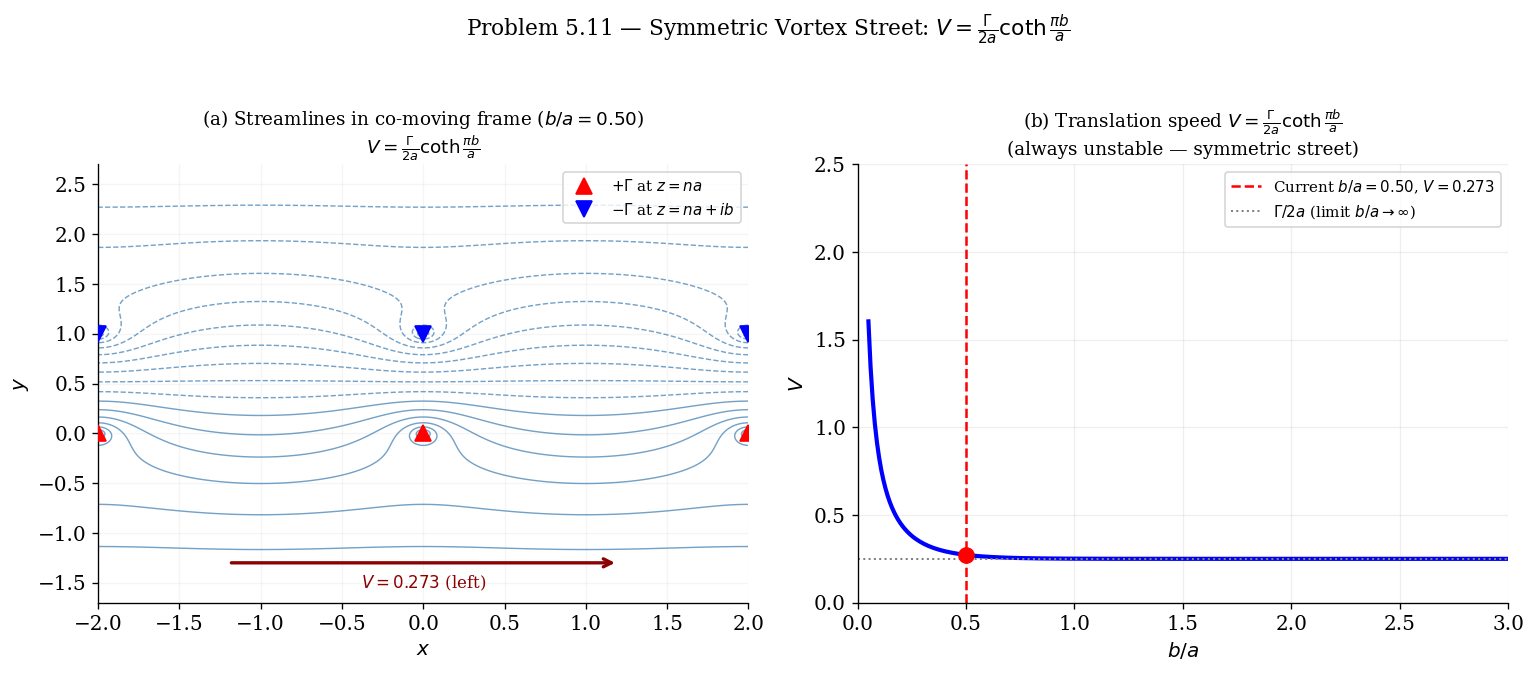

Saved: fig_5_11_vortex_street.png


In [5]:
\
Gamma_s, a_s, b_s = 1.0, 2.0, 1.0

xg = np.linspace(-a_s, a_s, 600)
yg = np.linspace(-b_s*1.5, b_s*2.5, 400)
Xg, Yg = np.meshgrid(xg, yg)
Zg = Xg + 1j*Yg

# Street speed
V_street = Gamma_s/(2*a_s) / np.tanh(np.pi*b_s/a_s)   # coth = 1/tanh

# Complex potential (regularise near integer multiples)
eps_s = 1e-12
arg1 = np.pi*Zg/a_s
arg2 = np.pi*(Zg - 1j*b_s)/a_s
W_s = (-1j*Gamma_s/(2*np.pi))*(np.log(np.sin(arg1)+eps_s)) \
    + ( 1j*Gamma_s/(2*np.pi))*(np.log(np.sin(arg2)+eps_s))

# Subtract moving-frame term: phi -> phi - V*x (i.e. W -> W - V*z in co-moving frame)
W_moving = W_s - V_street*Zg
PSI_moving = np.imag(W_moving)

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

# ── Left: streamlines in co-moving frame ─────────────────────────────────────
ax = axes[0]
levels_s = np.linspace(-2, 2, 40)
ax.contour(Xg, Yg, PSI_moving, levels=levels_s,
           colors='steelblue', linewidths=0.85, alpha=0.75)

# Vortex positions (one period)
for n in [-1, 0, 1]:
    ax.plot(n*a_s, 0,    'r^', ms=10, zorder=6)
    ax.plot(n*a_s, b_s,  'bv', ms=10, zorder=6)

ax.plot([], [], 'r^', ms=10, label='$+\\Gamma$ at $z=na$')
ax.plot([], [], 'bv', ms=10, label='$-\\Gamma$ at $z=na+ib$')
ax.annotate('', xy=(a_s*0.6, -b_s*1.3), xytext=(-a_s*0.6, -b_s*1.3),
            arrowprops=dict(arrowstyle='->', color='darkred', lw=2.0))
ax.text(0, -b_s*1.55, f'$V={V_street:.3f}$ (left)',
        ha='center', fontsize=10, color='darkred')

ax.set_xlabel('$x$'); ax.set_ylabel('$y$')
ax.set_title(f'(a) Streamlines in co-moving frame ($b/a={b_s/a_s:.2f}$)\n'
             r'$V = \frac{\Gamma}{2a}\coth\frac{\pi b}{a}$', fontsize=11)
ax.legend(fontsize=9, loc='upper right')
ax.set_xlim(-a_s, a_s); ax.set_ylim(-b_s*1.7, b_s*2.7)
ax.grid(True, alpha=0.12)

# ── Right: V vs b/a ───────────────────────────────────────────────────────────
ax = axes[1]
ba_arr = np.linspace(0.05, 3.0, 300)
V_arr  = Gamma_s/(2*a_s) / np.tanh(np.pi*ba_arr)

ax.plot(ba_arr, V_arr, 'b-', lw=2.5)
ax.axvline(b_s/a_s, color='r', lw=1.5, ls='--',
           label=f'Current $b/a={b_s/a_s:.2f}$, $V={V_street:.3f}$')
ax.axhline(Gamma_s/(2*a_s), color='gray', lw=1.2, ls=':',
           label=r'$\Gamma/2a$ (limit $b/a\to\infty$)')
ax.plot(b_s/a_s, V_street, 'ro', ms=9, zorder=6)

ax.set_xlabel('$b/a$')
ax.set_ylabel(r'$V\cdot 2a/\Gamma$' if False else '$V$')
ax.set_title(r'(b) Translation speed $V = \frac{\Gamma}{2a}\coth\frac{\pi b}{a}$'
             '\n(always unstable — symmetric street)', fontsize=11)
ax.legend(fontsize=9)
ax.set_xlim(0, 3); ax.set_ylim(0, 2.5)
ax.grid(True, alpha=0.2)

plt.suptitle(r'Problem 5.11 — Symmetric Vortex Street: $V=\frac{\Gamma}{2a}\coth\frac{\pi b}{a}$',
             fontsize=13, y=1.02)
plt.tight_layout(pad=1.2)
plt.savefig(FIG_DIR / 'fig_5_11_vortex_street.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig_5_11_vortex_street.png')

---
## Problem 5.14 — $n$ Vortices on a Circle

Left: streamlines for $n=4$ vortices rotating with $\Omega=(n-1)\Gamma/4\pi a^2$.
Right: $\Omega$ vs $n$ confirming linear growth.


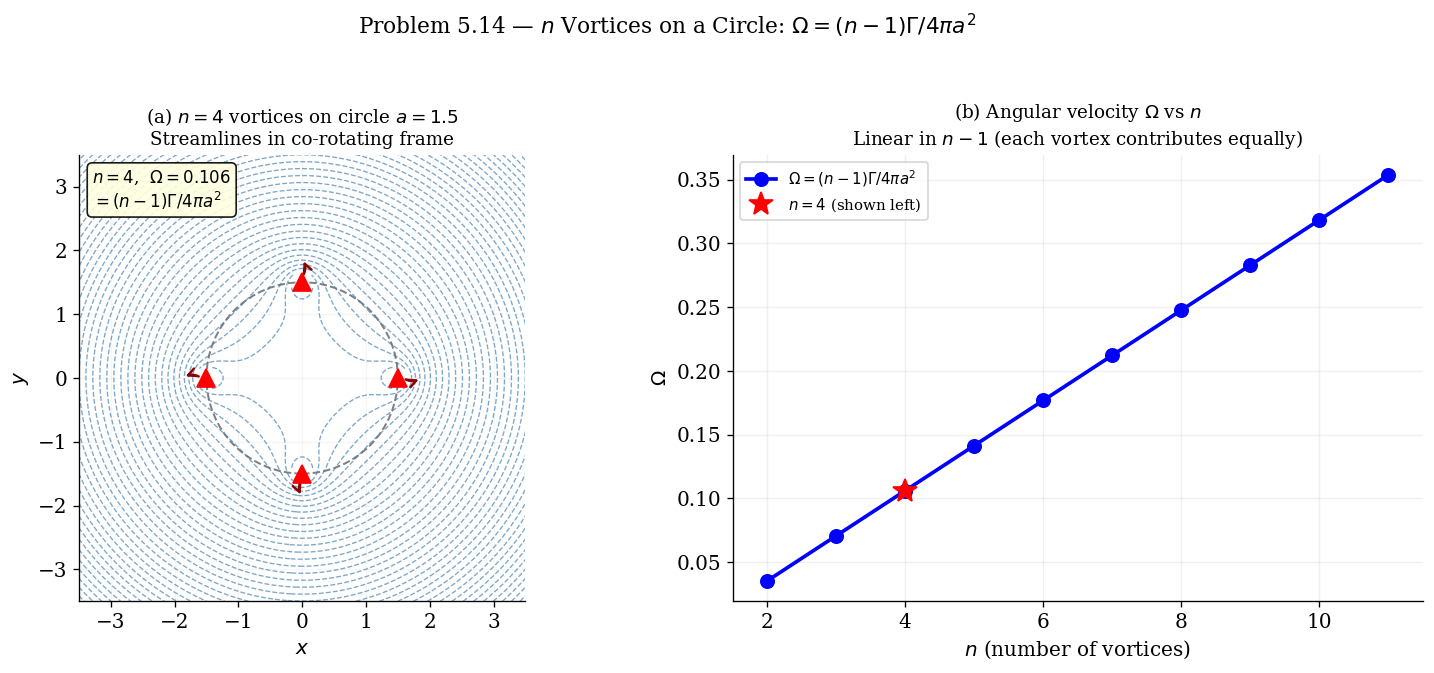

Saved: fig_5_14_rotating_array.png


In [6]:
\
Gamma_r = 1.0
a_r = 1.5

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

# ── Left: streamlines for n=4 ─────────────────────────────────────────────────
ax = axes[0]
n_show = 4
angles = np.linspace(0, 2*np.pi, n_show, endpoint=False)
z_vorts = a_r * np.exp(1j*angles)

xg = np.linspace(-3.5, 3.5, 600)
yg = np.linspace(-3.5, 3.5, 600)
Xg, Yg = np.meshgrid(xg, yg)
Zg = Xg + 1j*Yg

# Stream function: sum of log|z - z_k|
PSI_r = np.zeros_like(Xg)
for zk in z_vorts:
    PSI_r += -Gamma_r/(2*np.pi) * np.log(np.abs(Zg - zk) + 1e-8)

# Co-rotating frame: subtract Omega*(x^2+y^2)/2  (rigid rotation stream function)
Omega_r = (n_show-1)*Gamma_r/(4*np.pi*a_r**2)
PSI_rot = PSI_r - 0.5*Omega_r*(Xg**2+Yg**2)

# Mask near vortex cores
for zk in z_vorts:
    near_k = np.abs(Zg - zk) < 0.18
    PSI_rot = np.where(near_k, np.nan, PSI_rot)

ax.contour(Xg, Yg, PSI_rot, levels=40, colors='steelblue', linewidths=0.8, alpha=0.7)
circle = Circle((0,0), a_r, fill=False, ec='gray', lw=1.2, ls='--')
ax.add_patch(circle)

for i, zk in enumerate(z_vorts):
    ax.plot(zk.real, zk.imag, 'r^', ms=11, zorder=7)
    ax.annotate('', xy=(zk.real*1.25, zk.imag*1.25),
                xytext=(zk.real*1.05, zk.imag*1.05),
                arrowprops=dict(arrowstyle='->', color='darkred',
                                connectionstyle='arc3,rad=0.3', lw=1.5))

ax.text(0.03, 0.97,
        f'$n={n_show}$,  $\\Omega = {Omega_r:.3f}$\n'
        f'$= (n-1)\\Gamma/4\\pi a^2$',
        transform=ax.transAxes, fontsize=10, va='top',
        bbox=dict(boxstyle='round,pad=0.3', fc='lightyellow', alpha=0.9))

ax.set_xlabel('$x$'); ax.set_ylabel('$y$')
ax.set_title(f'(a) $n=4$ vortices on circle $a={a_r}$\n'
             r'Streamlines in co-rotating frame', fontsize=11)
ax.set_aspect('equal'); ax.set_xlim(-3.5,3.5); ax.set_ylim(-3.5,3.5)
ax.grid(True, alpha=0.12)

# ── Right: Omega vs n ─────────────────────────────────────────────────────────
ax = axes[1]
n_arr = np.arange(2, 12)
Omega_arr = (n_arr-1)*Gamma_r/(4*np.pi*a_r**2)

ax.plot(n_arr, Omega_arr, 'b-o', lw=2.2, ms=8, label=r'$\Omega=(n-1)\Gamma/4\pi a^2$')
ax.plot(n_show, Omega_r, 'r*', ms=15, zorder=6, label=f'$n={n_show}$ (shown left)')

# Linear fit annotation
ax.set_xlabel('$n$ (number of vortices)')
ax.set_ylabel(r'$\Omega\cdot 4\pi a^2/\Gamma$' if False else '$\\Omega$')
ax.set_title(r'(b) Angular velocity $\Omega$ vs $n$''\n'
             r'Linear in $n-1$ (each vortex contributes equally)', fontsize=11)
ax.legend(fontsize=9)
ax.set_xlim(1.5, 11.5); ax.grid(True, alpha=0.2)

plt.suptitle(r'Problem 5.14 — $n$ Vortices on a Circle: $\Omega=(n-1)\Gamma/4\pi a^2$',
             fontsize=13, y=1.02)
plt.tight_layout(pad=1.2)
plt.savefig(FIG_DIR / 'fig_5_14_rotating_array.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig_5_14_rotating_array.png')

---
## Problem 5.19 — Burgers Vortex

$u_\theta = \dfrac{\Gamma}{2\pi r}(1-e^{-\alpha r^2/4\nu})$,  $\omega = \dfrac{\Gamma\alpha}{4\pi\nu}e^{-\alpha r^2/4\nu}$

Left: velocity profiles for different $\alpha/\nu$. Right: vorticity profiles — Gaussian core.


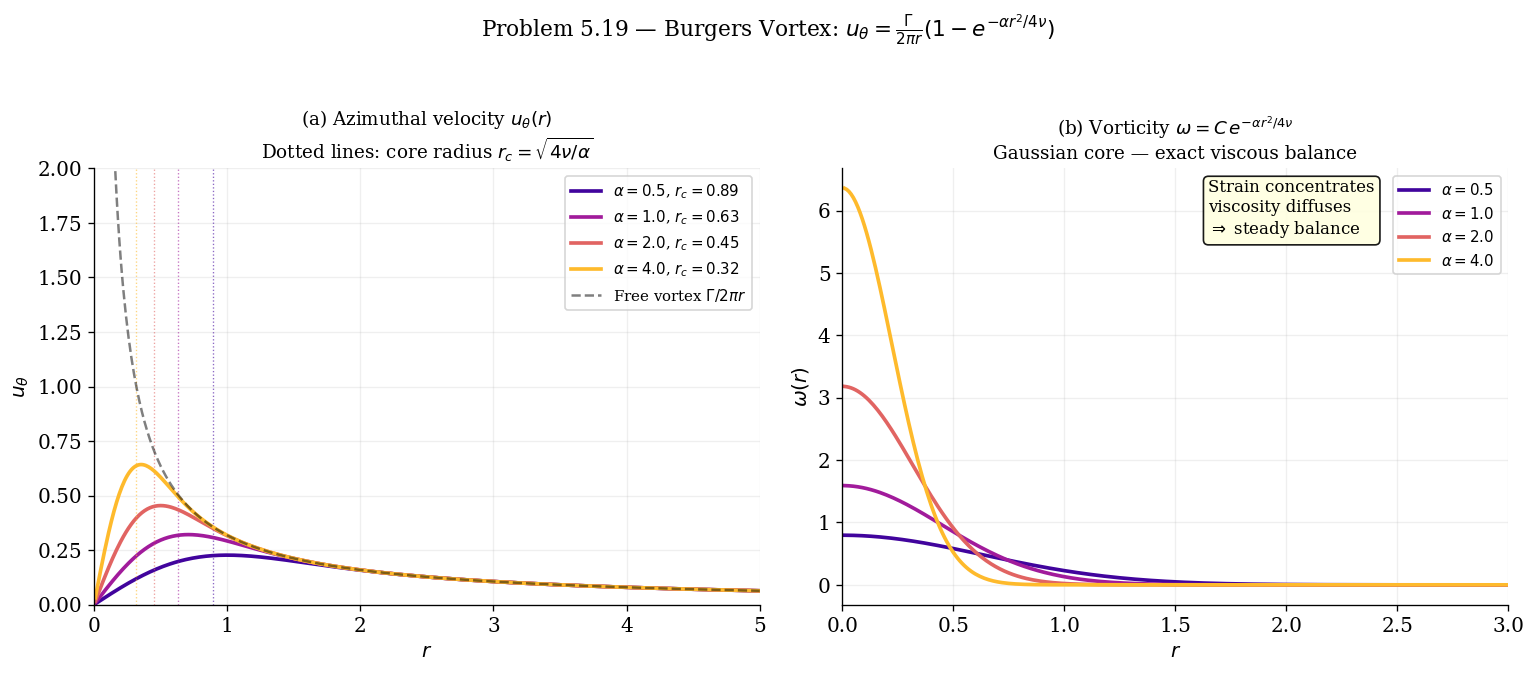

Saved: fig_5_19_burgers.png


In [7]:
\
Gamma_b = 2.0
nu_b    = 0.1

r_arr = np.linspace(0.01, 5.0, 500)

alpha_vals = [0.5, 1.0, 2.0, 4.0]
colors_b   = plt.cm.plasma(np.linspace(0.1, 0.85, len(alpha_vals)))

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

# ── Left: u_theta profiles ────────────────────────────────────────────────────
ax = axes[0]
for alpha_b, col in zip(alpha_vals, colors_b):
    rc = np.sqrt(4*nu_b/alpha_b)   # core radius
    u_th = Gamma_b/(2*np.pi*r_arr) * (1 - np.exp(-alpha_b*r_arr**2/(4*nu_b)))
    u_inf = Gamma_b/(2*np.pi*r_arr)  # free vortex
    ax.plot(r_arr, u_th, color=col, lw=2.2,
            label=f'$\\alpha={alpha_b}$, $r_c={rc:.2f}$')
    ax.axvline(rc, color=col, lw=0.8, ls=':', alpha=0.6)

ax.plot(r_arr, Gamma_b/(2*np.pi*r_arr), 'k--', lw=1.5, alpha=0.5,
        label=r'Free vortex $\Gamma/2\pi r$')
ax.set_xlabel('$r$'); ax.set_ylabel('$u_\\theta$')
ax.set_title(r'(a) Azimuthal velocity $u_\theta(r)$''\n'
             'Dotted lines: core radius $r_c=\\sqrt{4\\nu/\\alpha}$', fontsize=11)
ax.legend(fontsize=9)
ax.set_xlim(0, 5); ax.set_ylim(0, 2.0)
ax.grid(True, alpha=0.2)

# ── Right: vorticity profiles ─────────────────────────────────────────────────
ax = axes[1]
for alpha_b, col in zip(alpha_vals, colors_b):
    omega_b = Gamma_b*alpha_b/(4*np.pi*nu_b) * np.exp(-alpha_b*r_arr**2/(4*nu_b))
    ax.plot(r_arr, omega_b, color=col, lw=2.2,
            label=f'$\\alpha={alpha_b}$')

ax.set_xlabel('$r$')
ax.set_ylabel(r'$\omega(r)$')
ax.set_title('(b) Vorticity $\\omega = C\\,e^{-\\alpha r^2/4\\nu}$\n'
             'Gaussian core — exact viscous balance', fontsize=11)
ax.legend(fontsize=9)
ax.set_xlim(0, 3); ax.grid(True, alpha=0.2)

# Annotate balance
axes[1].text(0.55, 0.85,
    'Strain concentrates\nviscosity diffuses\n$\\Rightarrow$ steady balance',
    transform=axes[1].transAxes, fontsize=10,
    bbox=dict(boxstyle='round,pad=0.3', fc='lightyellow', alpha=0.9))

plt.suptitle(r'Problem 5.19 — Burgers Vortex: $u_\theta=\frac{\Gamma}{2\pi r}(1-e^{-\alpha r^2/4\nu})$',
             fontsize=13, y=1.02)
plt.tight_layout(pad=1.2)
plt.savefig(FIG_DIR / 'fig_5_19_burgers.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig_5_19_burgers.png')

---
## Problem 5.26 — Irrotational Flow Past a Sphere

$\phi = U\!\left(r+\dfrac{a^3}{2r^2}\right)\cos\theta$

Left: streamlines (cross-section). Right: surface pressure — fore–aft symmetry → zero drag.


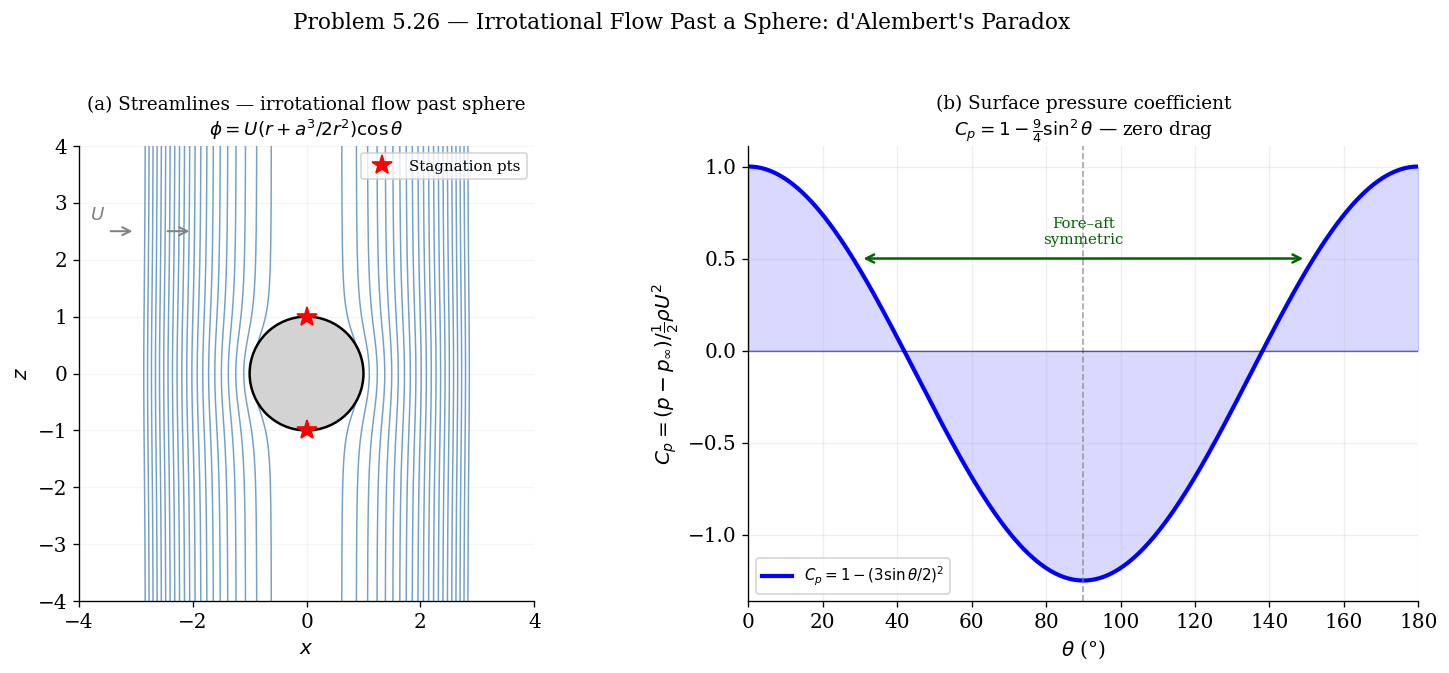

Saved: fig_5_26_sphere.png


In [8]:
\
U_sp, a_sp = 1.0, 1.0

# Streamlines in (x,z) plane (y=0), axisymmetric
xg = np.linspace(-4, 4, 600)
zg = np.linspace(-4, 4, 600)
Xsp, Zsp = np.meshgrid(xg, zg)
Rsp  = np.sqrt(Xsp**2 + Zsp**2)
Rsp  = np.where(Rsp < 1e-6, 1e-6, Rsp)
mask_sp = Rsp < a_sp
Thsp = np.arctan2(Xsp, Zsp)   # theta from z-axis

PHI = np.where(mask_sp, 0,
      U_sp*(Rsp + a_sp**3/(2*Rsp**2))*np.cos(Thsp))
# Stream function Psi = U sin^2(theta) (r^2 - a^3/(2r)) / r...
# Actually: Psi = U*sin^2(theta)*(r^2/2 - a^3/(4r)) ... wait:
# u_r = dPhi/dr, u_theta = (1/r)dPhi/dtheta
# Stream function for axisymmetric: Psi_stokes
PSI_sp = np.where(mask_sp, 0,
         U_sp*(Rsp**2 - a_sp**3/(2*Rsp))*np.sin(Thsp)**2 / 2)

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

# ── Left: streamlines ─────────────────────────────────────────────────────────
ax = axes[0]
PSI_masked = np.where(mask_sp, np.nan, PSI_sp)
levels_sp = np.linspace(0, 4, 22)
ax.contour(Xsp, Zsp, PSI_masked, levels=levels_sp,
           colors='steelblue', linewidths=0.9, alpha=0.75)
ax.contour(Xsp, Zsp, PSI_masked, levels=-np.flip(levels_sp[1:]),
           colors='steelblue', linewidths=0.9, alpha=0.75)

sphere = Circle((0,0), a_sp, color='lightgray', ec='k', lw=1.5, zorder=5)
ax.add_patch(sphere)

# Stagnation points
ax.plot(0,  a_sp, 'r*', ms=12, zorder=7, label='Stagnation pts')
ax.plot(0, -a_sp, 'r*', ms=12, zorder=7)

# Far-field arrows
for xi in [-3, -2]:
    ax.annotate('', xy=(xi, 2.5), xytext=(xi-0.5, 2.5),
                arrowprops=dict(arrowstyle='->', color='gray', lw=1.2))
ax.text(-3.8, 2.7, '$U$', fontsize=11, color='gray')

ax.set_xlabel('$x$'); ax.set_ylabel('$z$')
ax.set_title('(a) Streamlines — irrotational flow past sphere\n'
             r'$\phi=U(r+a^3/2r^2)\cos\theta$', fontsize=11)
ax.legend(fontsize=9, loc='upper right')
ax.set_aspect('equal'); ax.set_xlim(-4,4); ax.set_ylim(-4,4)
ax.grid(True, alpha=0.12)

# ── Right: surface pressure ────────────────────────────────────────────────────
ax = axes[1]
theta_p = np.linspace(0, np.pi, 300)
u_surf  = 1.5*U_sp*np.sin(theta_p)   # slip velocity
Cp      = 1 - (u_surf/U_sp)**2        # pressure coefficient: Cp=(p-p_inf)/(1/2 rho U^2)

ax.plot(np.degrees(theta_p), Cp, 'b-', lw=2.5,
        label=r'$C_p = 1-(3\sin\theta/2)^2$')
ax.fill_between(np.degrees(theta_p), Cp, 0, alpha=0.15, color='blue')

# Fore-aft symmetry arrow
ax.axvline(90, color='gray', lw=1.0, ls='--', alpha=0.7)
ax.annotate('', xy=(30, 0.5), xytext=(150, 0.5),
            arrowprops=dict(arrowstyle='<->', color='darkgreen', lw=1.5))
ax.text(90, 0.58, 'Fore–aft\nsymmetric', ha='center', fontsize=9, color='darkgreen')

ax.axhline(0, color='k', lw=0.8, ls='-', alpha=0.5)
ax.set_xlabel(r'$\theta$ (°)'); ax.set_ylabel('$C_p = (p-p_\\infty)/\\frac{1}{2}\\rho U^2$')
ax.set_title(r'(b) Surface pressure coefficient''\n'
             r'$C_p = 1 - \frac{9}{4}\sin^2\theta$ — zero drag', fontsize=11)
ax.legend(fontsize=9)
ax.set_xlim(0,180); ax.grid(True, alpha=0.2)

plt.suptitle(r"Problem 5.26 — Irrotational Flow Past a Sphere: d'Alembert's Paradox",
             fontsize=13, y=1.02)
plt.tight_layout(pad=1.2)
plt.savefig(FIG_DIR / 'fig_5_26_sphere.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig_5_26_sphere.png')

---
## Problem 5.28 — Closing Wedge Flow

$\phi = -\dfrac{\Omega r^2\cos 2\theta}{2\sin 2\Omega t}$, $\psi = -\dfrac{\Omega r^2\sin 2\theta}{2\sin 2\Omega t}$

Left: streamlines at three gap angles. Right: centreline velocity diverges as gap $\to\pi$.


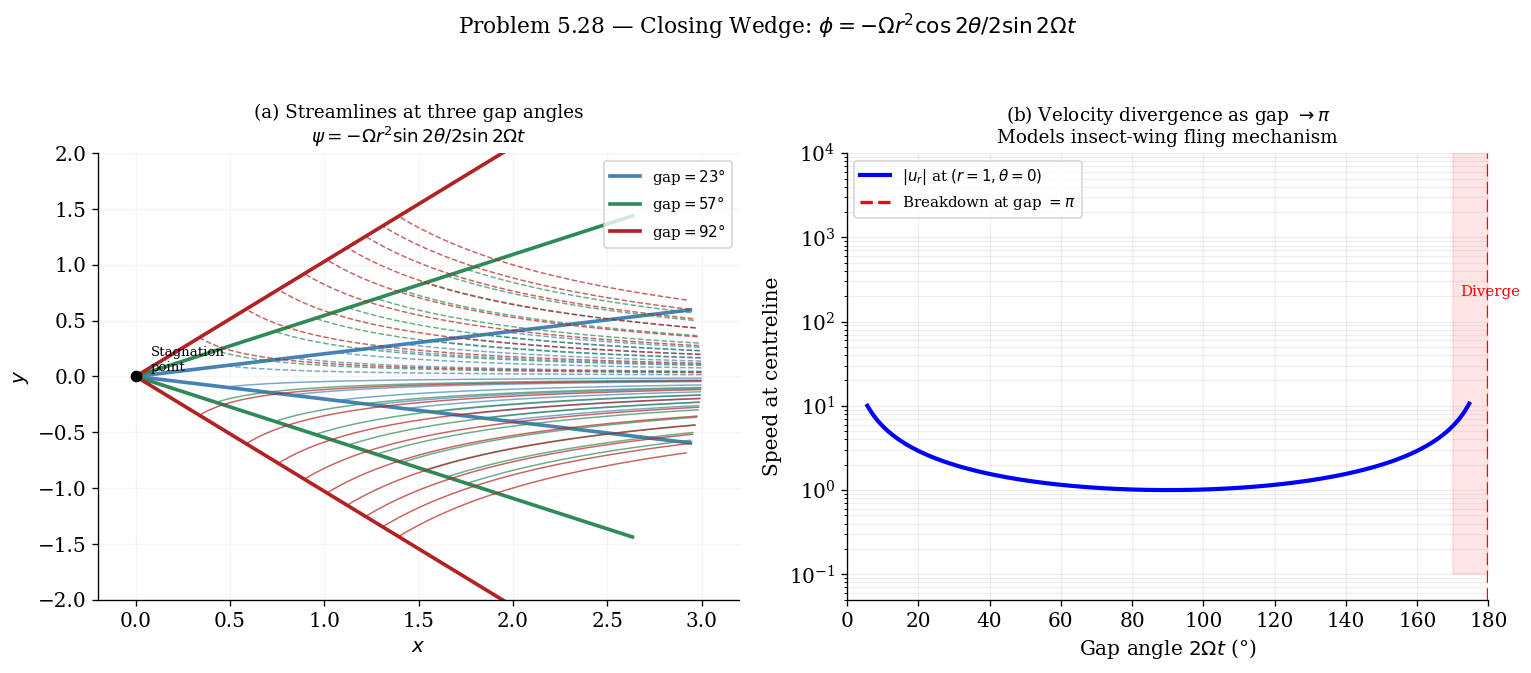

Saved: fig_5_28_wedge.png


In [9]:
\
Omega_wg = 1.0

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

# ── Left: streamlines at three gap angles ─────────────────────────────────────
ax = axes[0]
t_angles = [0.2, 0.5, 0.8]   # Omega*t values → gap = 2*Omega*t radians
colors_wg = ['steelblue', 'seagreen', 'firebrick']

for t_val, col in zip(t_angles, colors_wg):
    gap = 2*Omega_wg*t_val
    sin2Ot = np.sin(2*Omega_wg*t_val)

    r_w = np.linspace(0.0, 3.0, 400)
    th_w = np.linspace(-gap/2, gap/2, 400)
    Rw, Thw = np.meshgrid(r_w, th_w)
    PSI_wg = -Omega_wg*Rw**2*np.sin(2*Thw)/(2*sin2Ot)

    # Plot in Cartesian
    Xw = Rw*np.cos(Thw); Yw = Rw*np.sin(Thw)
    levels_wg = np.linspace(-2, 2, 18)
    ax.contour(Xw, Yw, PSI_wg, levels=levels_wg, colors=[col],
               linewidths=0.9, alpha=0.7)

    # Wall lines
    for sgn in [+1, -1]:
        r_wall = np.linspace(0, 3, 100)
        xw_ = r_wall*np.cos(sgn*gap/2)
        yw_ = r_wall*np.sin(sgn*gap/2)
        ax.plot(xw_, yw_, color=col, lw=2.2,
                label=f'gap$={np.degrees(gap):.0f}°$' if sgn==1 else '')

ax.plot(0, 0, 'ko', ms=6, zorder=7)
ax.text(0.08, 0.05, 'Stagnation\npoint', fontsize=8)
ax.set_xlabel('$x$'); ax.set_ylabel('$y$')
ax.set_title('(a) Streamlines at three gap angles\n'
             r'$\psi = -\Omega r^2\sin 2\theta/2\sin 2\Omega t$', fontsize=11)
ax.legend(fontsize=9, loc='upper right')
ax.set_xlim(-0.2, 3.2); ax.set_ylim(-2.0, 2.0)
ax.grid(True, alpha=0.12)

# ── Right: centreline velocity divergence ─────────────────────────────────────
ax = axes[1]
t_arr_wg = np.linspace(0.05, np.pi/(2*Omega_wg)*0.97, 400)
gap_arr  = 2*Omega_wg*t_arr_wg

# Speed at (r=1, theta=0) on centreline: u_theta = (1/r)dphi/dtheta|_{theta=0}
# dphi/dtheta = Omega*r^2*sin(2theta) / 2*sin2Ot → 0 at theta=0
# u_r = dphi/dr = -Omega*r*cos2theta/sin2Ot → at theta=0, r=1: -Omega/sin2Ot
speed_centre = Omega_wg / np.abs(np.sin(2*Omega_wg*t_arr_wg))

ax.semilogy(np.degrees(gap_arr), speed_centre, 'b-', lw=2.5,
            label=r'$|u_r|$ at $(r=1,\theta=0)$')
ax.axvline(180, color='r', lw=2.0, ls='--', label='Breakdown at gap $= \\pi$')
ax.fill_betweenx([1e-1, 1e4], 170, 180, alpha=0.1, color='red')
ax.text(172, 200, 'Diverge', fontsize=9, color='red')

ax.set_xlabel('Gap angle $2\\Omega t$ (°)')
ax.set_ylabel('Speed at centreline')
ax.set_title('(b) Velocity divergence as gap $\\to \\pi$\n'
             'Models insect-wing fling mechanism', fontsize=11)
ax.legend(fontsize=9)
ax.set_xlim(0, 180); ax.set_ylim(0.05, 1e4)
ax.grid(True, alpha=0.2, which='both')

plt.suptitle(r'Problem 5.28 — Closing Wedge: $\phi=-\Omega r^2\cos2\theta/2\sin2\Omega t$',
             fontsize=13, y=1.02)
plt.tight_layout(pad=1.2)
plt.savefig(FIG_DIR / 'fig_5_28_wedge.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig_5_28_wedge.png')

---
## Summary of saved figures

| File | Problem |
|------|---------|
| `fig_5_1_circuit.png`         | 5.1  Deforming circuit, circulation constant |
| `fig_5_8_corner_vortex.png`   | 5.8  Vortex in corner — image & path |
| `fig_5_10_wall_vortex.png`    | 5.10 Vortex near wall — drift & pressure |
| `fig_5_11_vortex_street.png`  | 5.11 Symmetric vortex street |
| `fig_5_14_rotating_array.png` | 5.14 $n$ vortices on a circle |
| `fig_5_19_burgers.png`        | 5.19 Burgers vortex profile |
| `fig_5_26_sphere.png`         | 5.26 Irrotational flow past sphere |
| `fig_5_28_wedge.png`          | 5.28 Closing wedge flow |


In [10]:
# ── Package all figures and download (Colab) ───────────────────────────────────
import zipfile
from pathlib import Path

zip_path = Path('ch05_figures.zip')
fig_files = [
    'fig_5_1_circuit.png',
    'fig_5_8_corner_vortex.png',
    'fig_5_10_wall_vortex.png',
    'fig_5_11_vortex_street.png',
    'fig_5_14_rotating_array.png',
    'fig_5_19_burgers.png',
    'fig_5_26_sphere.png',
    'fig_5_28_wedge.png',
]

with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zf:
    for fname in fig_files:
        fpath = FIG_DIR / fname
        if fpath.exists():
            zf.write(fpath, fname)
            print(f'  added: {fname}  ({fpath.stat().st_size/1024:.0f} KB)')
        else:
            print(f'  MISSING: {fname} — run the cell above first')

total_kb = zip_path.stat().st_size / 1024
print(f'\nZip: {zip_path}  ({total_kb:.0f} KB)')

try:
    from google.colab import files
    files.download(str(zip_path))
    print('Download started.')
except ImportError:
    print(f'Not in Colab — file saved locally at: {zip_path.resolve()}')

  added: fig_5_1_circuit.png  (151 KB)
  added: fig_5_8_corner_vortex.png  (230 KB)
  added: fig_5_10_wall_vortex.png  (292 KB)
  added: fig_5_11_vortex_street.png  (184 KB)
  added: fig_5_14_rotating_array.png  (416 KB)
  added: fig_5_19_burgers.png  (160 KB)
  added: fig_5_26_sphere.png  (203 KB)
  added: fig_5_28_wedge.png  (286 KB)

Zip: ch05_figures.zip  (1812 KB)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Download started.
